In [4]:
import pandas as pd
import plotly.graph_objects as go

# -------------------------------------------------------------------------
# Define Node Structure and Layout
# -------------------------------------------------------------------------
# This list maps every string label to a numeric index for Plotly's flow engine.
nodes = [
    # Level 0: Total Suite
    "rocm-examples",            # 0
    
    # Level 1: Core Outcomes
    "Success",             # 1
    "Failure",                 # 2
    
    # Level 2: Specific Targets (Successes & Exact Errors)
    "hip_streams [Placeholder: -- ms]", # 3
    "rocthrust_vectors [Placeholder: -- ms]", # 4
    "rocfft_complex_complex [Placeholder: -- ms]", # 5
    "rocsparse_spmv [Placeholder: -- ms]", # 6
    "rocsolver_getf2 [Placeholder: -- ms]", # 7
    "Runtime Error: \"Invalid Device Function\"", # 8
    "Tensile Error: \"Missing TensileLibrary.dat\"", # 9
    
    # Level 3: Individual Crashing Binaries
    "hip_warp_shuffle",                 # 10
    "hipcub_device_radix_sort",          # 11
    "rocblas_gemm",                     # 12
    "hipblas_gemm"                      # 13
]

# Define a professional color palette matching the sleekness of your seaborn layout
# We use RGBA values to create beautiful, semi-transparent flows (alpha=0.35)
color_map = {
    "neutral": "rgba(100, 116, 139, 0.8)",   # Slate for root node
    "success": "rgba(44, 123, 182, 0.8)",    # Muted Blue matching palette_pair
    "failure": "rgba(215, 25, 28, 0.8)",     # Crimson Red matching palette_pair
    
    "flow_success": "rgba(44, 123, 182, 0.35)",
    "flow_failure": "rgba(215, 25, 28, 0.35)"
}

# Assign distinct color properties to every node block dynamically
node_colors = [
    color_map["neutral"],  # 0: Root
    color_map["success"],  # 1: Success branch
    color_map["failure"],  # 2: Failure branch
    color_map["success"], color_map["success"], color_map["success"], color_map["success"], color_map["success"], # 3-7: Success nodes
    color_map["failure"], color_map["failure"], # 8-9: Specific Error Blocks
    color_map["failure"], color_map["failure"], color_map["failure"], color_map["failure"]  # 10-13: Crashing binaries
]

# -------------------------------------------------------------------------
# Define the Flows (Sources, Targets, and Flow Values)
# -------------------------------------------------------------------------
# Each triplet represents: [Source Index, Target Index, Flow Volume Weight]
flows = [
    # Top Level System Splits (5 Successful Binaries, 4 Crashing Binaries)
    [0, 1, 5], 
    [0, 2, 4],
    
    # Success Branch Distribution (Equal weights for placeholders)
    [1, 3, 1],
    [1, 4, 1],
    [1, 5, 1],
    [1, 6, 1],
    [1, 7, 1],
    
    # Failure Branch -> Classified by Root Exception Types
    [2, 8, 2],  # Routed to Invalid Device Function
    [2, 9, 2],  # Routed to Missing Tensile Library
    
    # Error Blocks -> Split to exact terminal binary signatures
    [8, 10, 1], # Invalid Device Function -> warp_shuffle
    [8, 11, 1], # Invalid Device Function -> radix_sort
    [9, 12, 1], # Missing Tensile -> rocblas_gemm
    [9, 13, 1]  # Missing Tensile -> hipblas_gemm
]

# Unpack flow structures for Plotly visualization consumption
sources = [f[0] for f in flows]
targets = [f[1] for f in flows]
values = [f[2] for f in flows]

# Set the flow path transparency colors conditionally based on branch destination
link_colors = [
    color_map["flow_success"] if t == 1 or (s in [1, 3, 4, 5, 6, 7]) 
    else color_map["flow_failure"] 
    for s, t in zip(sources, targets)
]

# -------------------------------------------------------------------------
# Construct and Render the Sankey Figure
# -------------------------------------------------------------------------
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=20,                 # Vertical padding between node blocks
        thickness=20,           # Thickness width of structural node lines
        line=dict(color="rgba(255, 255, 255, 0.8)", width=1),
        label=nodes,
        color=node_colors
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values,
        color=link_colors
    )
)])

# Style configurations for elegant print or web presentation layout
fig.update_layout(
    title_text="rocm-examples v6.4.2 on gfx90c (installed via dnf, no spoofing)",
    title_font=dict(size=18, family="Adwaita Mono", color="#1e293b"),
    font_size=14,
    font_family="Adwaita Sans",
    width=1100,
    height=650,
    plot_bgcolor="white",
    paper_bgcolor="white"
)

# Save high-fidelity file output cleanly to working directory
fig.write_image("rocm_execution_sankey.png", scale=2)
fig.show()

Sankey saved to: rocm_type_subcategory_outcome_sankey.png


Runtime chart saved to: rocm_success_runtime_seaborn.png


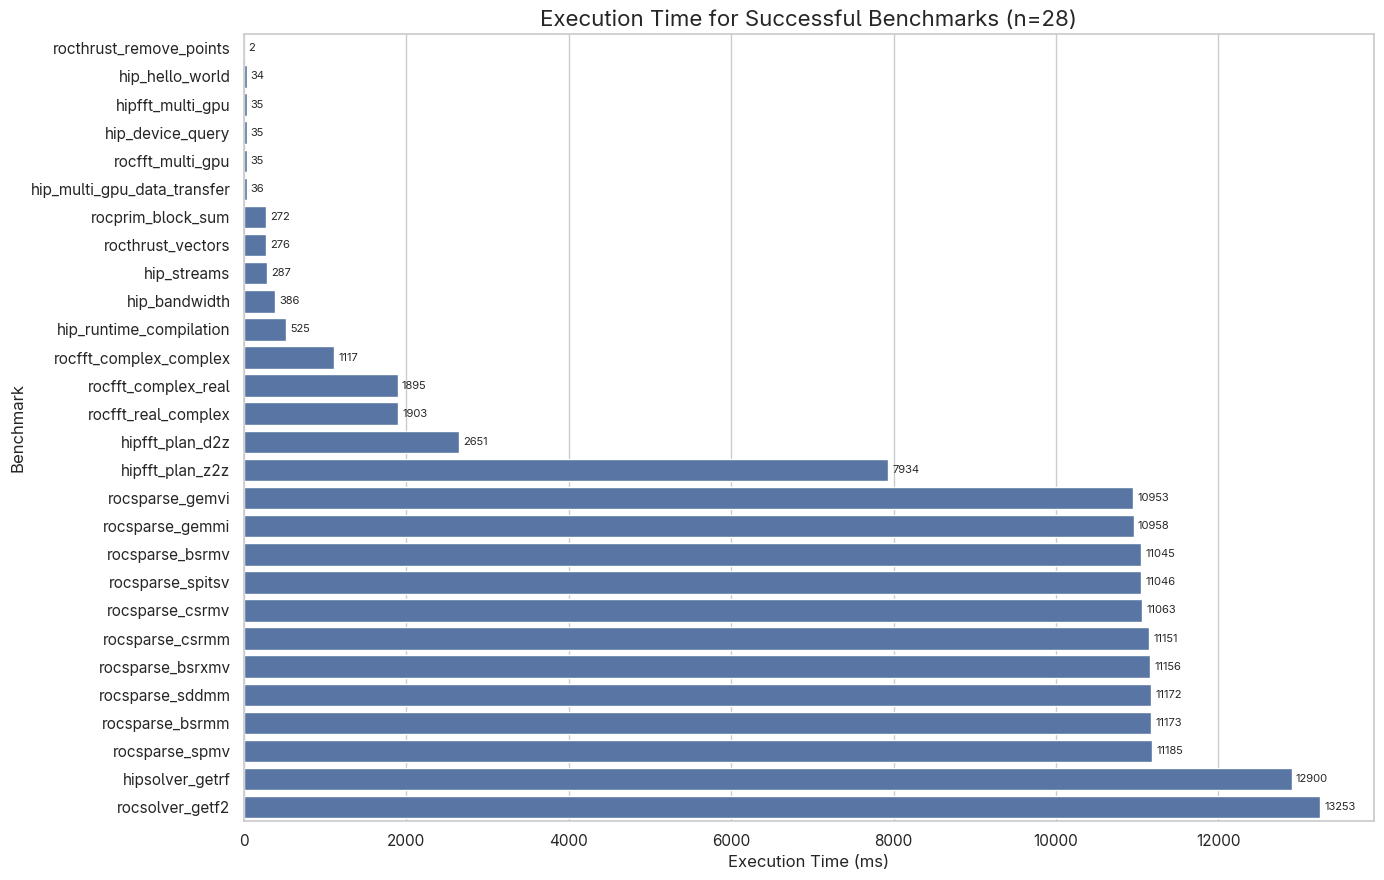

In [7]:
import os
from collections import defaultdict

import pandas as pd
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt

# -------------------------------------------------------------------------
# Load and Clean Benchmark Records
# -------------------------------------------------------------------------
csv_path = "/home/netherquark/Soham/Soham/Coding/AMD/ROCm/Experiments/rocm-examples from dnf/benchmark_results.csv"
if not os.path.exists(csv_path):
    raise FileNotFoundError(f"Missing '{csv_path}'.")

df = pd.read_csv(csv_path, sep="|")
df["error_category"] = df["error_category"].fillna("Unknown Error")

# -------------------------------------------------------------------------
# Helpers: type + subcategory classification
# -------------------------------------------------------------------------
def benchmark_type(binary: str) -> str:
    # Simple rule: roc* -> ROC, everything else -> HIP
    return "ROC" if binary.startswith("roc") else "HIP"

def benchmark_subcategory(binary: str) -> str:
    prefix = binary.split("_")[0]

    # Human-friendly labels, kept unique once combined with type
    labels = {
        "hip": "Core",
        "applications": "Applications",
        "reduction": "Reduction",
        "hipblas": "BLAS",
        "hipcub": "CUB",
        "hipfft": "FFT",
        "hipsolver": "Solver",
        "rocblas": "BLAS",
        "rocfft": "FFT",
        "rocprim": "Prim",
        "rocrand": "Rand",
        "rocsolver": "Solver",
        "rocsparse": "Sparse",
        "rocthrust": "Thrust",
    }
    return labels.get(prefix, prefix.capitalize())

df["benchmark_type"] = df["binary"].apply(benchmark_type)
df["subcategory"] = df["binary"].apply(benchmark_subcategory)

# -------------------------------------------------------------------------
# Build Sankey flows:
# rocm-examples -> HIP/ROC -> type:subcategory -> Success/Failure -> error_category
# -------------------------------------------------------------------------
root_node = "rocm-examples"
success_node = "Success"
failure_node = "Failure"

nodes = [root_node, success_node, failure_node]
flows = []

def sub_node_name(t: str, s: str) -> str:
    return f"{t}: {s}"

for _, row in df.iterrows():
    t = row["benchmark_type"]              # HIP / ROC
    s = row["subcategory"]                 # BLAS / Sparse / etc.
    sub_node = sub_node_name(t, s)

    nodes.extend([t, sub_node])

    # Root -> type
    flows.append((root_node, t, 1))
    # Type -> subcategory
    flows.append((t, sub_node, 1))

    if row["status"] == "Success":
        # Subcategory -> Success
        flows.append((sub_node, success_node, 1))
    else:
        err = row["error_category"]
        nodes.append(err)
        # Subcategory -> Failure -> error category
        flows.append((sub_node, failure_node, 1))
        flows.append((failure_node, err, 1))

# Deduplicate node labels while preserving order
unique_nodes = list(dict.fromkeys(nodes))
node_indices = {name: idx for idx, name in enumerate(unique_nodes)}

# Aggregate identical links
aggregated_flows = defaultdict(int)
for src, tgt, val in flows:
    aggregated_flows[(node_indices[src], node_indices[tgt])] += val

plotly_sources = []
plotly_targets = []
plotly_values = []
for (s_idx, t_idx), val in aggregated_flows.items():
    plotly_sources.append(s_idx)
    plotly_targets.append(t_idx)
    plotly_values.append(val)

# -------------------------------------------------------------------------
# Colors
# -------------------------------------------------------------------------
color_map = {
    "neutral": "rgba(100, 116, 139, 0.80)",
    "hip": "rgba(59, 130, 246, 0.80)",
    "roc": "rgba(16, 185, 129, 0.80)",
    "success": "rgba(44, 123, 182, 0.80)",
    "failure": "rgba(215, 25, 28, 0.80)",
    "error": "rgba(239, 68, 68, 0.70)",
    "flow_success": "rgba(44, 123, 182, 0.25)",
    "flow_failure": "rgba(215, 25, 28, 0.25)",
}

node_colors = []
for name in unique_nodes:
    if name == root_node:
        node_colors.append(color_map["neutral"])
    elif name == success_node:
        node_colors.append(color_map["success"])
    elif name == failure_node:
        node_colors.append(color_map["failure"])
    elif name in ("HIP", "ROC"):
        node_colors.append(color_map["hip"] if name == "HIP" else color_map["roc"])
    elif ": " in name:
        # type:subcategory nodes
        node_colors.append(color_map["hip"] if name.startswith("HIP:") else color_map["roc"])
    else:
        # error categories
        node_colors.append(color_map["error"])

link_colors = []
for s_idx, t_idx in zip(plotly_sources, plotly_targets):
    source_name = unique_nodes[s_idx]
    target_name = unique_nodes[t_idx]

    if target_name in (success_node,) or source_name == success_node:
        link_colors.append(color_map["flow_success"])
    elif target_name == failure_node or source_name == failure_node or target_name in df["error_category"].unique():
        link_colors.append(color_map["flow_failure"])
    else:
        # root -> type, type -> subcategory
        link_colors.append("rgba(100, 116, 139, 0.22)")

# -------------------------------------------------------------------------
# Sankey figure
# -------------------------------------------------------------------------
fig = go.Figure(
    data=[
        go.Sankey(
            node=dict(
                pad=14,
                thickness=18,
                line=dict(color="rgba(255, 255, 255, 0.9)", width=0.5),
                label=unique_nodes,
                color=node_colors,
            ),
            link=dict(
                source=plotly_sources,
                target=plotly_targets,
                value=plotly_values,
                color=link_colors,
            ),
        )
    ]
)

fig.update_layout(
    title_text=f"rocm-examples v6.4.2 on gfx90c (installed via dnf, no spoofing) (Total Tests: {len(df)})",
    title_font=dict(size=24, family="Adwaita Mono, monospace", color="#1e293b"),
    font_size=20,
    font_family="Adwaita Sans, sans-serif",
    width=1400,
    height=950,
    plot_bgcolor="white",
    paper_bgcolor="white",
)

sankey_output = "rocm_type_subcategory_outcome_sankey.png"
fig.write_image(sankey_output, scale=2)
print(f"Sankey saved to: {sankey_output}")
fig.show()

# -------------------------------------------------------------------------
# Separate seaborn chart for successful runtime only
# -------------------------------------------------------------------------
success_df = df[df["status"] == "Success"].copy()
success_df = success_df.sort_values("execution_time_ms", ascending=True)

sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "Adwaita Sans"

plt.figure(figsize=(14, max(6, 0.32 * len(success_df))))
ax = sns.barplot(
    data=success_df,
    y="binary",
    x="execution_time_ms",
    order=success_df["binary"],
)

ax.set_title(
    f"Execution Time for Successful Benchmarks (n={len(success_df)})",
    fontsize=16,
)
ax.set_xlabel("Execution Time (ms)")
ax.set_ylabel("Benchmark")

# Optional value labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3, fontsize=8)

plt.tight_layout()
runtime_output = "rocm_success_runtime_seaborn.png"
plt.savefig(runtime_output, dpi=200, bbox_inches="tight")
print(f"Runtime chart saved to: {runtime_output}")
plt.show()